In [ ]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"NumPy version: {np.__version__}")
print("\nall packages loaded successfully")

✓ PyTorch version: 2.10.0+cpu
✓ Torchvision version: 0.25.0+cpu
✓ CUDA available: False
✓ NumPy version: 2.4.1
Kaggle API token set

 all packages loaded successfully


In [ ]:
import os
from dotenv import load_dotenv

#set up Kaggle dataset API
load_dotenv()

KAGGLE_API_TOKEN = os.getenv('KAGGLE_API_TOKEN')

if KAGGLE_API_TOKEN:
    os.environ['KAGGLE_API_TOKEN'] = KAGGLE_API_TOKEN
    print("API token loaded from .env")
else:
    print("API token not found")

os.makedirs('data/raw', exist_ok=True)

In [ ]:
import os
os.makedirs('data/raw', exist_ok=True)
#download data set
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p data/raw --unzip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other




  0%|          | 0.00/2.29G [00:00<?, ?B/s]
  0%|          | 2.00M/2.29G [00:00<02:39, 15.4MB/s]
  0%|          | 7.00M/2.29G [00:00<01:20, 30.5MB/s]
  0%|          | 11.0M/2.29G [00:00<01:11, 34.4MB/s]
  1%|          | 15.0M/2.29G [00:00<01:07, 36.4MB/s]
  1%|          | 19.0M/2.29G [00:00<01:03, 38.2MB/s]
  1%|          | 23.0M/2.29G [00:00<01:03, 38.3MB/s]
  1%|          | 28.0M/2.29G [00:00<00:57, 42.5MB/s]
  1%|▏         | 33.0M/2.29G [00:00<00:53, 45.1MB/s]
  2%|▏         | 39.0M/2.29G [00:01<00:50, 47.9MB/s]
  2%|▏         | 44.0M/2.29G [00:01<00:49, 48.8MB/s]
  2%|▏         | 49.0M/2.29G [00:01<00:49, 48.3MB/s]
  2%|▏         | 55.0M/2.29G [00:01<00:47, 50.1MB/s]
  3%|▎         | 61.0M/2.29G [00:01<00:46, 51.8MB/s]
  3%|▎         | 69.0M/2.29G [00:01<00:39, 60.0MB/s]
  3%|▎         | 76.0M/2.29G [00:01<00:37, 63.8MB/s]
  4%|▎         | 84.0M/2.29G [00:01<00:36, 64.8MB/s]
  4%|▍         | 92.0M/2.29G [00:01<00:34, 68.3MB/s]
  4%|▍         | 99.0M/2.29G [00:01<00:34, 68.9MB/s]
 

In [21]:
from pathlib import Path

base_path = Path('data/raw/chest_xray')

if base_path.exists():
    print("Dataset downloaded succesfully\n")
    print("Dir structure:")
    print(f"    {base_path}\\")

    for split in ['train', 'test', 'val']:
        split_path = base_path / split
        if split_path.exists():
            normal_count = len(list((split_path / 'NORMAL').glob('*.jpeg')))
            pneumonia_count = len(list((split_path / 'PNEUMONIA').glob('*.jpeg')))
            total = normal_count + pneumonia_count

            print(f"\n  {split.upper()} ({total:,} images):")
            print(f"     ├──NORMAL: {normal_count:,}")
            print(f"     └──PNEUMONIA: {pneumonia_count:,}")
        else:
            print(f"\n {split} Dataset not found") 
            print(f" Expected in {split_path}")
        

Dataset downloaded succesfully

Dir structure:
    data\raw\chest_xray\

  TRAIN (5,216 images):
     ├──NORMAL: 1,341
     └──PNEUMONIA: 3,875

  TEST (624 images):
     ├──NORMAL: 234
     └──PNEUMONIA: 390

  VAL (16 images):
     ├──NORMAL: 8
     └──PNEUMONIA: 8


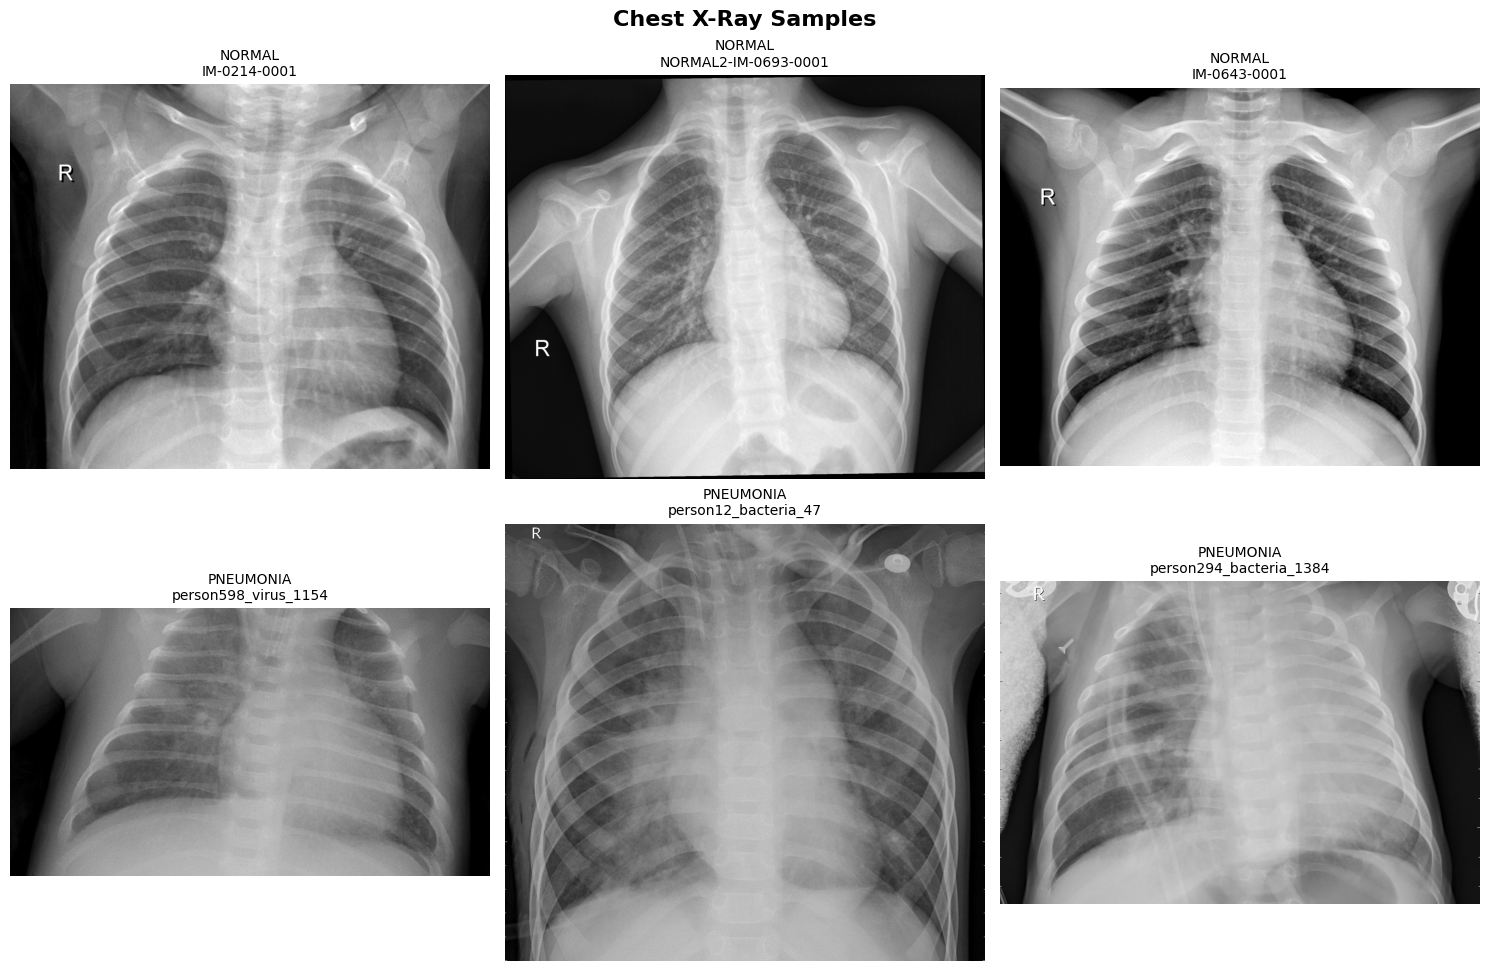

In [46]:
import matplotlib.pyplot as plt
from PIL import Image
import random

normal_images = list((base_path / 'train' / 'NORMAL').glob('*.jpeg'))
pneumonia_images = list((base_path / 'train' / 'PNEUMONIA').glob('*.jpeg'))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Chest X-Ray Samples', fontsize=16, fontweight='bold')

for i in range(3):
    img_path = random.choice(normal_images)
    img = Image.open(img_path)
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'NORMAL\n{img_path.stem[:30]}', fontsize=10)
    axes[0, i].axis('off')

for j in range(3):
    img_path = random.choice(pneumonia_images)
    img = Image.open(img_path)
    axes[1, j].imshow(img, cmap='gray')
    axes[1, j].set_title(f'PNEUMONIA\n{img_path.stem[:30]}', fontsize=10)
    axes[1, j].axis('off')

plt.tight_layout()
plt.show()